# Tutorial 1: Basic Pattern Generation

In this tutorial, you'll learn how to generate artificial XRD patterns from CIF files using the galaxi package.

These are the patterns that will eventually be used to train machine learning models. The key is to generate *artificial* patterns that look as *realistic* as possible. This is accomplished by introducing experimental artifacts like peak shifts and broadening, background noise, impurity phases, *etc.* - all of which arise frequently in experiment.


## Basic Setup and Imports

Let's start by importing the necessary modules and setting up our environment:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

# Import galaxi modules
from galaxi.core.pattern_generator import UnifiedPatternGenerator
from galaxi.core.config import XRDGenerationConfig
from galaxi.visualization import XRDVisualizer

# Set up paths
tutorial_dir = Path(".")  # Current directory (tutorials)
cif_dir = tutorial_dir / "data" / "cif_files"
results_dir = tutorial_dir / "results"
results_dir.mkdir(exist_ok=True)

print("Available CIF files:")
for cif_file in cif_dir.glob("*.cif"):
    print(f"  - {cif_file.name}")

Available CIF files:
  - Li3PO4_9012500.cif
  - Li2O_108886.cif
  - Mn2O3_159865.cif
  - NiO_112314.cif
  - ZrO2_2180450.cif
  - NaNO3_2310364.cif
  - Li2TiO3_15150.cif
  - Co3O4_1538531.cif
  - TiO2_121632.cif
  - MnO_643195.cif
  - MnF2_14142.cif
  - LiF_18012.cif
  - TiO2_82657.cif
  - Li2CO3_100324.cif
  - MnO2_643186.cif
  - Li2MnO3_117607.cif
  - LiMnO2_15105.cif
  - LiMn2O4_111081.cif


## Understanding XRD Generation Configuration

The `XRDGenerationConfig` class controls all aspects of pattern generation. Let's explore its parameters:

In [2]:
# Create a basic configuration
config = XRDGenerationConfig(
    
    # Angular range and resolution
    min_angle=10.0,                           # Start angle (degrees 2θ)
    max_angle=80.0,                           # End angle (degrees 2θ)
    num_points=4501,                          # Number of points in the pattern

    # Whether to convert into Q-space
    convert_to_q=False,                       # False means stay in 2θ
    
    # Peak position effects
    uniform_shift_range=(-0.1, 0.1),          # Peak position shifts (degrees)
    sample_displacement=(-0.1, 0.1),          # Sample displacement (in mm)
    
    # Crystallite size and strain parameters
    crystallite_size_range=(10.0, 50.0),      # Crystallite size in nm
    microstrain_range=(0.0, 0.002),           # Microstrain: (0.002 = 0.2%)
    lattice_strain_range=(0.0, 0.01),         # Lattice strain (0.01 = 1%)
    
    # Temperature effects
    temperature_range=(250, 350),             # Temperature range (K)
    atomic_displacement_range=(0.005, 0.02),  # Atomic displacement parameters (Å²)
    
    # Texture and preferred orientation
    texture_range=(0.8, 1.2),                 # Preferred orientation (0.8-1.2 = 80-120% intensity change)
    
    # Background and noise
    background_level=(1.0, 3.0),              # Background intensity range (1-3% of max peak intensity)
    noise_level=(0.1, 0.3),                   # Random noise level (0.1-0.3% of max peak intensity)
    
    # Diffuse scattering and amorphous content
    diffuse_scattering_intensity=(0.0, 10.0), # Diffuse scattering contribution (0-10% of max peak intensity)
    amorphous_intensity=(0.0, 15.0),          # Amorphous phase contribution (0-15% of max peak intensity)
    
    # Impurity peaks
    enable_impurities=True,                   # Add impurity peaks
    impurity_intensity_range=(0.0, 5.0)       # Impurity peak intensity range (0-5% of max peak intensity)
)

print("Configuration created with the following settings:")
print(f"Angular range: {config.min_angle}° to {config.max_angle}°")
print(f"Peak shift range: {config.uniform_shift_range}")
print(f"Crystallite size range: {config.crystallite_size_range} nm")
print(f"Microstrain range: {config.microstrain_range}")
print(f"Temperature range: {config.temperature_range} K")
print(f"Background level: {config.background_level}")
print(f"Noise level: {config.noise_level}")
print(f"Impurities enabled: {config.enable_impurities}")

Configuration created with the following settings:
Angular range: 10.0° to 80.0°
Peak shift range: (-0.1, 0.1)
Crystallite size range: (10.0, 50.0) nm
Microstrain range: (0.0, 0.002)
Temperature range: (250, 350) K
Background level: (1.0, 3.0)
Noise level: (0.1, 0.3)
Impurities enabled: True


### Explanations of the parameters for pattern generation

- **Angular Range**: Defines the 2θ range for pattern calculation. Typically, we set this to 10-80° for Cu K-alpha radiation.
- **Number of points:** How many points to sample in the pattern. 4501 points (the default) will give a very high resolution.
- **Peak Position Effects**: `uniform_shift_range` simulates uniform angular shifts, `sample_displacement` models sample positioning errors.
- **Crystallite Size**: Smaller crystallites produce broader peaks due to size broadening.
- **Microstrain**: Internal strain in crystals causes additional peak broadening.
- **Lattice Strain**: Changes to the unit cell lattice parameters that systematically modify peak positions.
- **Temperature Effects**: Temperature-dependent atomic displacement parameters affecting peak intensities.
- **Texture Range**: Models preferred orientation effects on peak intensities.
- **Background Level**: Constant background intensity due to amorphous phases or air scattering.
- **Noise Level**: Random noise simulating detector limitations and counting statistics.
- **Diffuse Scattering**: Contribution from thermal diffuse scattering and disorder.
- **Amorphous Content**: Broad signal from amorphous phases.
- **Impurity Peaks**: Random spurious peaks simulating impurities in the sample.

## Single-Phase Pattern Generation and Visualization

Let's generate our first XRD pattern from a single phase:

In [3]:
# Initialize the pattern generator
generator = UnifiedPatternGenerator(reference_dir=str(cif_dir), config=config)

# Generate a single-phase pattern for TiO2
cif_file = cif_dir / "TiO2_121632.cif"

print(f"\nGenerating pattern for {cif_file.name}...")

# Generate the pattern
pattern_data = generator.generate_single_phase_pattern(
    cif_file=str(cif_file),
    target_concentration=1.0,  # 100% pure phase
    include_metadata=True      # Include generation parameters in output
)

# Extract the pattern and metadata
two_theta = pattern_data['two_theta']
intensity = pattern_data['intensity']
metadata = pattern_data['metadata']

print(f"Pattern generated with {len(two_theta)} data points")
print(f"2θ range: {two_theta.min():.1f}° to {two_theta.max():.1f}°")
print(f"Intensity range: {intensity.min():.1f} to {intensity.max():.1f}")
print(f"Applied crystallite size: {metadata['crystallite_size']:.1f} nm")
print(f"Applied microstrain: {metadata['microstrain']:.4f}")

Discovered 18 reference phases (structures will be lazily loaded)

Generating pattern for TiO2_121632.cif...
Pattern generated with 4501 data points
2θ range: 10.0° to 80.0°
Intensity range: 0.0 to 1.0
Applied crystallite size: 37.2 nm
Applied microstrain: 0.0001


Now let's plot the generated pattern.

Figure saved as tutorials/results/single_phase_pattern.png


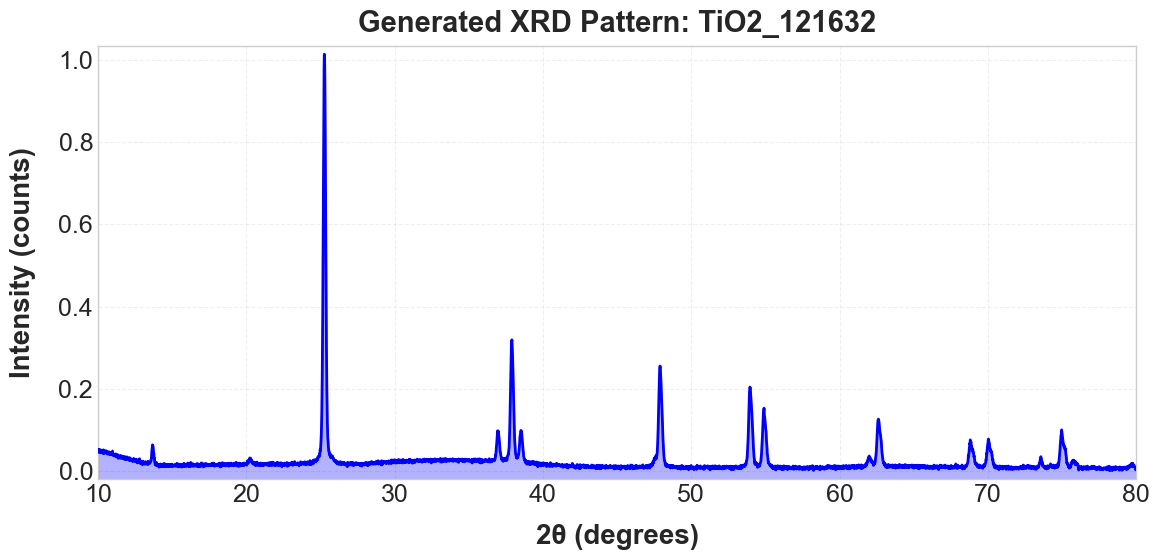

In [4]:
# Create a visualizer for high-quality plots
visualizer = XRDVisualizer(figsize=(12, 6), dpi=150)

# Plot and save in one step using XRDVisualizer's built-in method plot_pattern()
fig, ax = visualizer.plot_pattern(
  x_values=two_theta,
  intensity=intensity,
  title=f"Generated XRD Pattern: {cif_file.stem}",
  xlabel="2θ (degrees)",
  ylabel="Intensity (counts)",
  color='blue',
  save=True,
  filename=str(results_dir / "single_phase_pattern"),
  save_format="png",
  show=True
)

### Individual Artifact Types

Let's go through and visualize some specific artifacts commonly seen in real (experimental) XRD measurements:

#### Peak Broadening

Discovered 18 reference phases (structures will be lazily loaded)
Discovered 18 reference phases (structures will be lazily loaded)
Discovered 18 reference phases (structures will be lazily loaded)




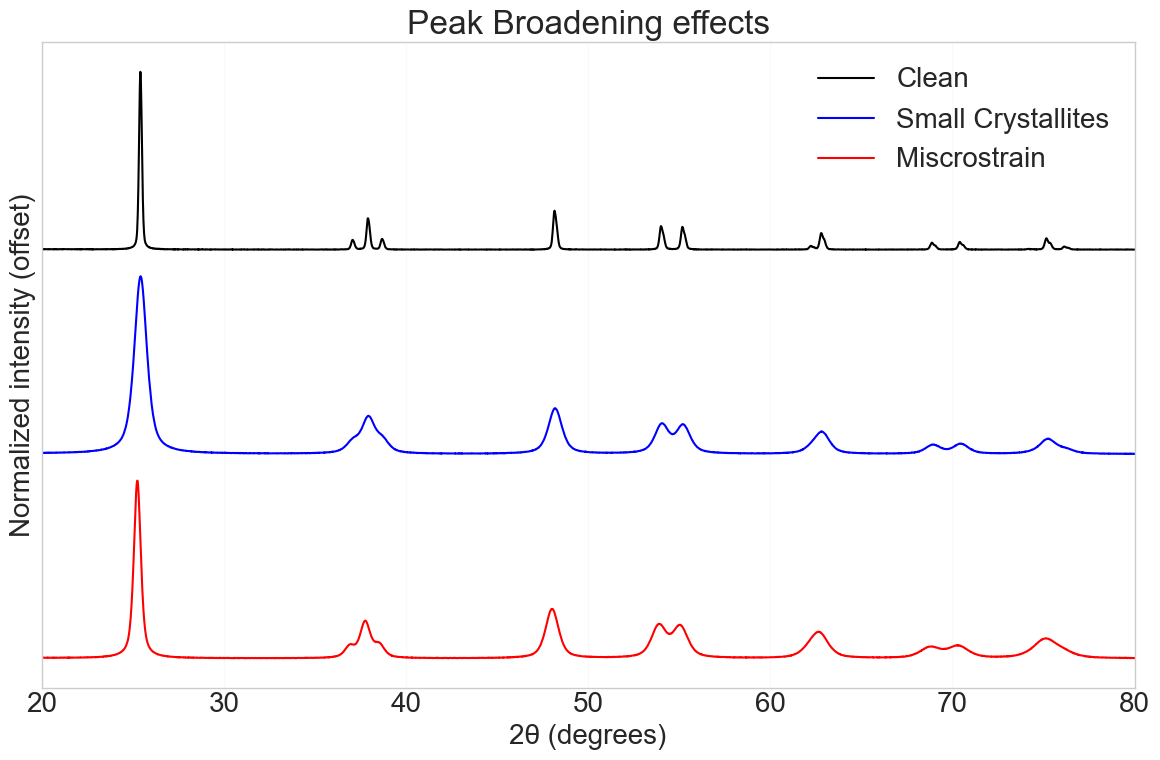

In [5]:
# Generate patterns showing different types of peak broadening
strain_patterns = {}

# Small crystallite effect
small_crys_config = XRDGenerationConfig(
    min_angle=10.0, max_angle=80.0,
    uniform_shift_range=(0.0, 0.0),
    crystallite_size_range=(10.0, 10.0),      # SMALL CRYSTALLITE SIZE (10 nm)
    microstrain_range=(0.0, 0.0),
    lattice_strain_range=(0.0, 0.0),
    temperature_range=(300, 300),
    texture_range=(1.0, 1.0),
    background_level=(0.5, 0.5),
    noise_level=(0.05, 0.05),
    diffuse_scattering_intensity=(0.0, 0.0),
    amorphous_intensity=(0.0, 0.0),
    enable_impurities=False
)

# Microstrain effect
microstrain_config = XRDGenerationConfig(
    min_angle=10.0, max_angle=80.0,
    uniform_shift_range=(0.0, 0.0),
    crystallite_size_range=(50.0, 50.0),
    microstrain_range=(0.008, 0.008),         # HIGH MICROSTRAIN (0.8%)
    lattice_strain_range=(0.0, 0.0),
    temperature_range=(300, 300),
    texture_range=(1.0, 1.0),
    background_level=(0.5, 0.5),
    noise_level=(0.05, 0.05),
    diffuse_scattering_intensity=(0.0, 0.0),
    amorphous_intensity=(0.0, 0.0),
    enable_impurities=False
)

# Clean reference (no strain)
clean_config = XRDGenerationConfig(
    min_angle=10.0, max_angle=80.0,
    uniform_shift_range=(0.0, 0.0),
    crystallite_size_range=(50.0, 50.0),
    microstrain_range=(0.0, 0.0),
    lattice_strain_range=(0.0, 0.0),
    temperature_range=(300, 300),
    texture_range=(1.0, 1.0),
    background_level=(0.5, 0.5),
    noise_level=(0.05, 0.05),
    diffuse_scattering_intensity=(0.0, 0.0),
    amorphous_intensity=(0.0, 0.0),
    enable_impurities=False
)

configs = {
    'Clean': clean_config,
    'Small Crystallites': small_crys_config,
    'Miscrostrain': microstrain_config
}

# Generate patterns
for label, config in configs.items():
    gen = UnifiedPatternGenerator(reference_dir=str(cif_dir), config=config)
    pattern = gen.generate_single_phase_pattern(
        cif_file=str(cif_dir / "TiO2_121632.cif"),
        target_concentration=1.0,
        include_metadata=True
    )
    strain_patterns[label] = pattern

# Plot strain comparison
print('\n')
fig, ax = plt.subplots(figsize=(12, 8))
colors = ['black', 'blue', 'red']
# Stack the patterns: scale each to a common peak height, then offset by
# slightly more than that height so each trace's peaks rise nearly to the
# trace above it rather than flattening against a shared intensity axis.
STACK_STEP = 1.15

for i, (label, pattern) in enumerate(strain_patterns.items()):
    intensity = np.asarray(pattern['intensity'], dtype=float)
    ax.plot(pattern['two_theta'], intensity / intensity.max() - i * STACK_STEP,
            color=colors[i], label=label, linewidth=1.5)

ax.set_xlabel("2θ (degrees)")
ax.set_ylabel("Normalized intensity (offset)")
ax.set_title("Peak Broadening effects")
ax.legend()
ax.grid(True, alpha=0.1)
ax.set_xlim(20, 80)
ax.set_yticks([])

plt.tight_layout()
plt.savefig(results_dir / "strain_effects.png", dpi=300, bbox_inches='tight')
plt.show()

Small crystallites lead to symmetric peak broadening, whereas high microstrain causes asymmetric broadening.

These differences are generally quite subtle - so you may not notice them - but the machine learning model (hopefully) will.

#### Temperature Effects

Discovered 18 reference phases (structures will be lazily loaded)
Discovered 18 reference phases (structures will be lazily loaded)
Discovered 18 reference phases (structures will be lazily loaded)




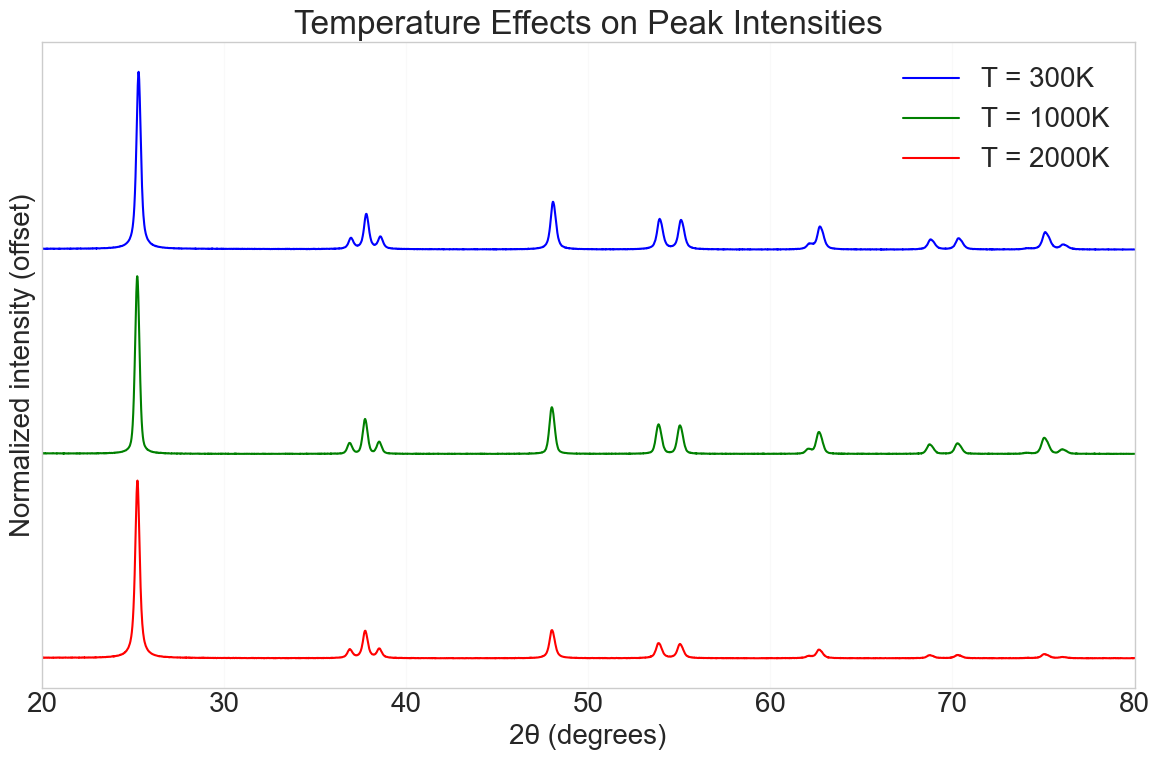

In [6]:
# Generate patterns at different temperatures
temperature_patterns = {}
temperatures = [300, 1000, 2000]  # Kelvin
atomic_disps = [0.0001, 0.001, 0.01]

for temp, adp in zip(temperatures, atomic_disps):
    temp_config = XRDGenerationConfig(
        min_angle=10.0, max_angle=80.0,
        uniform_shift_range=(0.0, 0.0),
        crystallite_size_range=(30.0, 30.0),
        microstrain_range=(0.0, 0.0),
        lattice_strain_range=(0.0, 0.0),
        temperature_range=(temp, temp),               # TEMPERATURE
        atomic_displacement_range=(adp, adp),         # THERMAL MOTION
        texture_range=(1.0, 1.0),
        background_level=(0.5, 0.5),
        noise_level=(0.05, 0.05),
        diffuse_scattering_intensity=(0.0, 0.0),
        amorphous_intensity=(0.0, 0.0),
        enable_impurities=False
    )

    gen = UnifiedPatternGenerator(reference_dir=str(cif_dir), config=temp_config)
    pattern = gen.generate_single_phase_pattern(
        cif_file=str(cif_dir / "TiO2_121632.cif"),
        target_concentration=1.0
    )
    temperature_patterns[f"{temp}K"] = pattern

# Plot temperature effects
print('\n')
fig, ax = plt.subplots(figsize=(12, 8))
colors = ['blue', 'green', 'red']

# Scale each pattern to a common peak height before stacking (see above)
for i, (label, pattern) in enumerate(temperature_patterns.items()):
    intensity = np.asarray(pattern['intensity'], dtype=float)
    ax.plot(pattern['two_theta'], intensity / intensity.max() - i * 1.15,
            color=colors[i], label=f"T = {label}", linewidth=1.5)

ax.set_xlabel("2θ (degrees)")
ax.set_ylabel("Normalized intensity (offset)")
ax.set_title("Temperature Effects on Peak Intensities")
ax.legend()
ax.grid(True, alpha=0.1)
ax.set_xlim(20, 80)
ax.set_yticks([])

plt.tight_layout()
plt.savefig(results_dir / "temperature_effects.png", dpi=300, bbox_inches='tight')
plt.show()

Higher temperatures and larger atomic displacements (due to increased thermal motion) lead to reduced peak intensities at higher angles.

These effects are described by the Debye-Waller factor:
exp(-2M) where M = 8π²<u²>sin²θ/λ² × (temperature/300)

So temperature amplifies the effect of atomic displacement beyond just setting the mean atomic displacement (u) value. Higher temperatures make the same u value have a stronger intensity-reducing effect on the peaks at high values of 2θ.


#### Preferred Orientation (Texture)

Discovered 18 reference phases (structures will be lazily loaded)
Discovered 18 reference phases (structures will be lazily loaded)
Discovered 18 reference phases (structures will be lazily loaded)




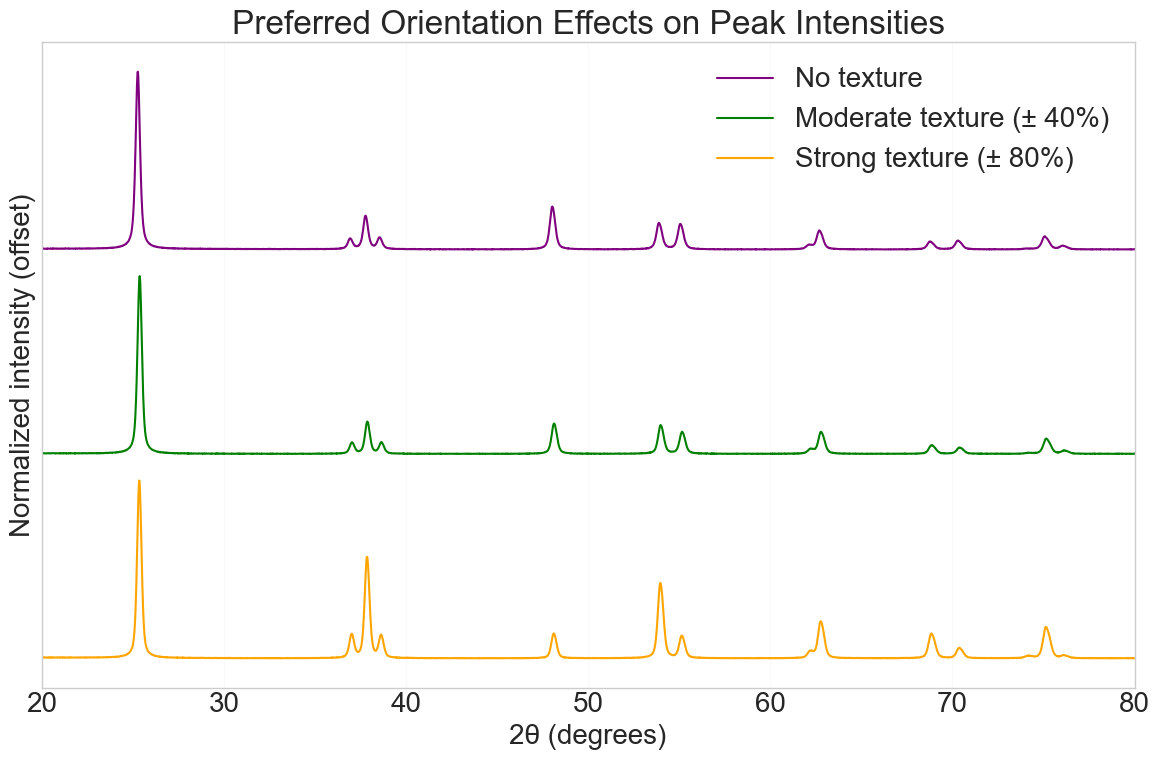

In [7]:
# Generate patterns with different texture effects
texture_patterns = {}
texture_values = [0.0, 0.4, 0.8]

for texture in texture_values:
    texture_config = XRDGenerationConfig(
        min_angle=10.0, max_angle=80.0,
        uniform_shift_range=(0.0, 0.0),
        crystallite_size_range=(30.0, 30.0),
        microstrain_range=(0.0, 0.0),
        lattice_strain_range=(0.0, 0.0),
        temperature_range=(300, 300),
        texture_range=(1-texture, 1+texture),            # PREFERRED ORIENTATION
        background_level=(0.5, 0.5),
        noise_level=(0.05, 0.05),
        diffuse_scattering_intensity=(0.0, 0.0),
        amorphous_intensity=(0.0, 0.0),
        enable_impurities=False
    )

    gen = UnifiedPatternGenerator(reference_dir=str(cif_dir), config=texture_config)
    pattern = gen.generate_single_phase_pattern(
        cif_file=str(cif_dir / "TiO2_121632.cif"),
        target_concentration=1.0
    )

    if texture == 0:
        label = "No texture"
    elif texture == 0.4:
        label = "Moderate texture (± 40%)"
    else:
        label = "Strong texture (± 80%)"

    texture_patterns[label] = pattern

# Plot texture effects
print('\n')
fig, ax = plt.subplots(figsize=(12, 8))
colors = ['purple', 'green', 'orange']

# Scale each pattern to a common peak height before stacking
for i, (label, pattern) in enumerate(texture_patterns.items()):
    intensity = np.asarray(pattern['intensity'], dtype=float)
    ax.plot(pattern['two_theta'], intensity / intensity.max() - i * 1.15,
            color=colors[i], label=label, linewidth=1.5)

ax.set_xlabel("2θ (degrees)")
ax.set_ylabel("Normalized intensity (offset)")
ax.set_title("Preferred Orientation Effects on Peak Intensities")
ax.legend()
ax.grid(True, alpha=0.1)
ax.set_xlim(20, 80)
ax.set_yticks([])

plt.tight_layout()
plt.savefig(results_dir / "texture_effects.png", dpi=300, bbox_inches='tight')
plt.show()

Preferred orientation (also known as texture) in powder samples often causes certain crystallographic planes to show up more often than others. The result is a modulation of relative peak intensities in XRD.

#### Background and Noise Effects

Discovered 18 reference phases (structures will be lazily loaded)
Discovered 18 reference phases (structures will be lazily loaded)
Discovered 18 reference phases (structures will be lazily loaded)
Discovered 18 reference phases (structures will be lazily loaded)
Discovered 18 reference phases (structures will be lazily loaded)
Discovered 18 reference phases (structures will be lazily loaded)




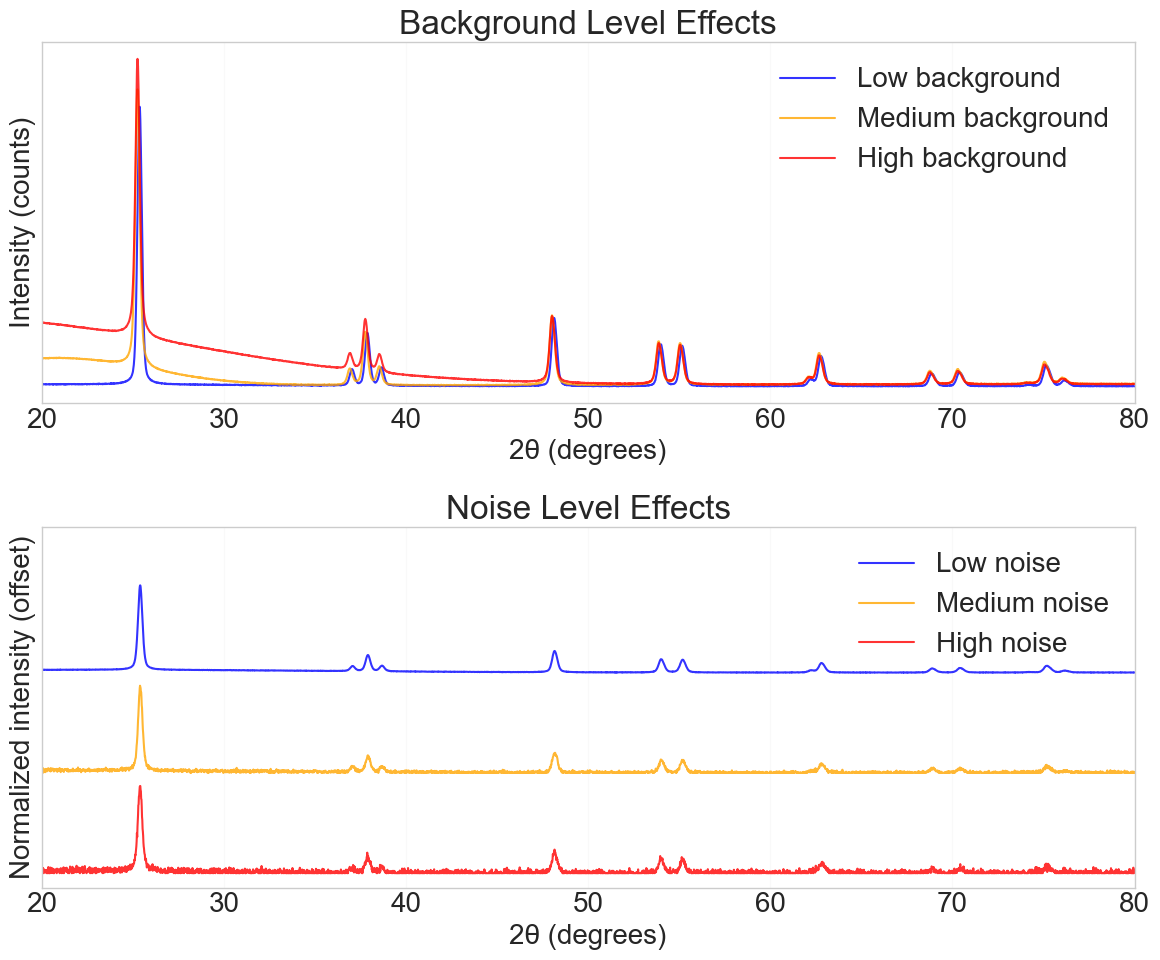

In [8]:
# Generate patterns with different background and noise levels
background_patterns = {}

# Different background scenarios
backgrounds = {
    'Low background': 1.0,
    'Medium background': 15.0,
    'High background': 30.0
}

noises = {
    'Low noise': 0.1,
    'Medium noise': 1.0,
    'High noise': 2.0
}

# Generate patterns with different background levels
for bg_label, bg_level in backgrounds.items():
    bg_config = XRDGenerationConfig(
        min_angle=10.0, max_angle=80.0,
        uniform_shift_range=(0.0, 0.0),
        crystallite_size_range=(30.0, 30.0),
        microstrain_range=(0.0, 0.0),
        lattice_strain_range=(0.0, 0.0),
        temperature_range=(300, 300),
        texture_range=(1.0, 1.0),
        background_level=(bg_level, bg_level),                    # BACKGROUND LEVEL
        noise_level=(0.05, 0.05),
        diffuse_scattering_intensity=(0.0, 0.0),
        amorphous_intensity=(0.0, 0.0),
        enable_impurities=False
    )

    gen = UnifiedPatternGenerator(reference_dir=str(cif_dir), config=bg_config)
    pattern = gen.generate_single_phase_pattern(
        cif_file=str(cif_dir / "TiO2_121632.cif"),
        target_concentration=1.0
    )
    background_patterns[bg_label] = pattern

# Plot background effects
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Background effects
colors = ['blue', 'orange', 'red']
for i, (label, pattern) in enumerate(background_patterns.items()):
    ax1.plot(pattern['two_theta'], pattern['intensity'],
            color=colors[i], label=label, linewidth=1.5, alpha=0.8)

ax1.set_xlabel("2θ (degrees)")
ax1.set_ylabel("Intensity (counts)")
ax1.set_title("Background Level Effects")
ax1.legend()
ax1.grid(True, alpha=0.1)
ax1.set_xlim(20, 80)
ax1.set_yticks([])

# Generate patterns with different noise levels
noise_patterns = {}
for noise_label, noise_level in noises.items():
    noise_config = XRDGenerationConfig(
        min_angle=10.0, max_angle=80.0,
        uniform_shift_range=(0.0, 0.0),
        crystallite_size_range=(30.0, 30.0),
        microstrain_range=(0.0, 0.0),
        lattice_strain_range=(0.0, 0.0),
        temperature_range=(300, 300),
        texture_range=(1.0, 1.0),
        background_level=(5.0, 5.0),
        noise_level=(noise_level, noise_level),             # NOISE LEVEL
        diffuse_scattering_intensity=(0.0, 0.0),
        amorphous_intensity=(0.0, 0.0),
        enable_impurities=False
    )

    gen = UnifiedPatternGenerator(reference_dir=str(cif_dir), config=noise_config)
    pattern = gen.generate_single_phase_pattern(
        cif_file=str(cif_dir / "TiO2_121632.cif"),
        target_concentration=1.0
    )
    noise_patterns[noise_label] = pattern

# Noise effects
# Scale each pattern to a common peak height before stacking
for i, (label, pattern) in enumerate(noise_patterns.items()):
    intensity = np.asarray(pattern['intensity'], dtype=float)
    ax2.plot(pattern['two_theta'], intensity / intensity.max() - i * 1.15,
            color=colors[i], label=label, linewidth=1.5, alpha=0.8)

ax2.set_xlabel("2θ (degrees)")
ax2.set_ylabel("Normalized intensity (offset)")
ax2.set_title("Noise Level Effects")
# Headroom so the legend clears the topmost trace
ax2.set_ylim(top=ax2.get_ylim()[1] + 0.5)
ax2.legend()
ax2.grid(True, alpha=0.1)
ax2.set_xlim(20, 80)
ax2.set_yticks([])

print('\n')
plt.tight_layout()
plt.savefig(results_dir / "background_noise_effects.png", dpi=300, bbox_inches='tight')
plt.show()

#### Peak Position Shifts

Discovered 18 reference phases (structures will be lazily loaded)
Discovered 18 reference phases (structures will be lazily loaded)
Discovered 18 reference phases (structures will be lazily loaded)
Discovered 18 reference phases (structures will be lazily loaded)
Discovered 18 reference phases (structures will be lazily loaded)
Discovered 18 reference phases (structures will be lazily loaded)




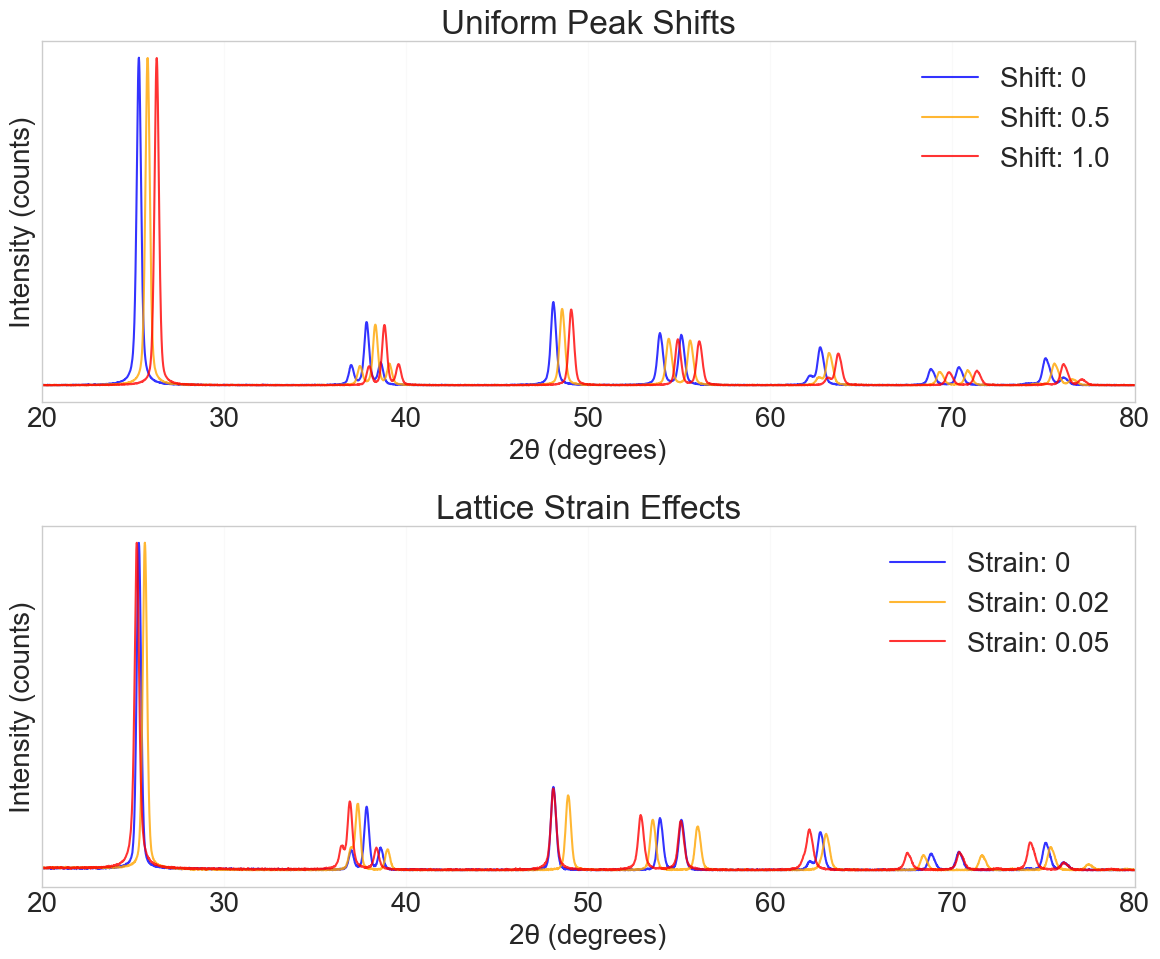

In [9]:
# Generate patterns with different peak shift effects
unif_patterns = {}

# Type 1: uniform shifts caused by goniometer calibration errors
uniform_shifts = [0, 0.5, 1.0]

# Type 2: non-uniform shifts caused by lattice strain
strain_shifts = [0, 0.02, 0.05]

# Generate patterns with varied uniform peak shifts
for unif_shift in uniform_shifts:
    ps_config = XRDGenerationConfig(
        min_angle=10.0, max_angle=80.0,
        uniform_shift_range=(unif_shift, unif_shift),        # APPLY UNIFORM PEAK SHIFTS
        crystallite_size_range=(30.0, 30.0),
        microstrain_range=(0.0, 0.0),
        lattice_strain_range=(0.0, 0.0),
        temperature_range=(300, 300),
        texture_range=(1.0, 1.0),
        background_level=(0, 0),
        noise_level=(0.05, 0.05),
        diffuse_scattering_intensity=(0.0, 0.0),
        amorphous_intensity=(0.0, 0.0),
        enable_impurities=False
    )

    gen = UnifiedPatternGenerator(reference_dir=str(cif_dir), config=ps_config)
    pattern = gen.generate_single_phase_pattern(
        cif_file=str(cif_dir / "TiO2_121632.cif"),
        target_concentration=1.0
    )
    label = f"Shift: {unif_shift}"
    unif_patterns[label] = pattern

# Plot background effects
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Background effects
colors = ['blue', 'orange', 'red']
for i, (label, pattern) in enumerate(unif_patterns.items()):
    ax1.plot(pattern['two_theta'], pattern['intensity'],
            color=colors[i], label=label, linewidth=1.5, alpha=0.8)

ax1.set_xlabel("2θ (degrees)")
ax1.set_ylabel("Intensity (counts)")
ax1.set_title("Uniform Peak Shifts")
ax1.legend()
ax1.grid(True, alpha=0.1)
ax1.set_xlim(20, 80)
ax1.set_yticks([])

# Generate patterns with different noise levels
strain_patterns = {}
for str_shift in strain_shifts:
    ps_config = XRDGenerationConfig(
        min_angle=10.0, max_angle=80.0,
        uniform_shift_range=(0.0, 0.0),
        crystallite_size_range=(30.0, 30.0),
        microstrain_range=(0.0, 0.0),
        lattice_strain_range=(str_shift, str_shift),      # APPLY LATTICE STRAIN
        temperature_range=(300, 300),
        texture_range=(1.0, 1.0),
        background_level=(1.0, 1.0),
        noise_level=(0.1, 0.1),
        diffuse_scattering_intensity=(0.0, 0.0),
        amorphous_intensity=(0.0, 0.0),
        enable_impurities=False
    )

    gen = UnifiedPatternGenerator(reference_dir=str(cif_dir), config=ps_config)
    pattern = gen.generate_single_phase_pattern(
        cif_file=str(cif_dir / "TiO2_121632.cif"),
        target_concentration=1.0
    )
    label = f"Strain: {str_shift}"
    strain_patterns[label] = pattern

# Noise effects
for i, (label, pattern) in enumerate(strain_patterns.items()):
    ax2.plot(pattern['two_theta'], pattern['intensity'],
            color=colors[i], label=label, linewidth=1.5, alpha=0.8)

ax2.set_xlabel("2θ (degrees)")
ax2.set_ylabel("Intensity (counts)")
ax2.set_title("Lattice Strain Effects")
ax2.legend()
ax2.grid(True, alpha=0.1)
ax2.set_xlim(20, 80)
ax2.set_yticks([])

print('\n')
plt.tight_layout()
plt.savefig(results_dir / "peak_shift_patterns.png", dpi=300, bbox_inches='tight')
plt.show()

In the top panel, we applied uniform shifts that reflect calibration errors in the diffractometer. In the bottom panel, we applied some changes to the lattice parameters of the phase itself, which leads to peak shifts that vary with angle. Typically, peaks at higher angles will exhibit larger shifts in accordance with Bragg's law.

#### Amorphous Content and Diffuse Scattering

Discovered 18 reference phases (structures will be lazily loaded)
Discovered 18 reference phases (structures will be lazily loaded)
Discovered 18 reference phases (structures will be lazily loaded)




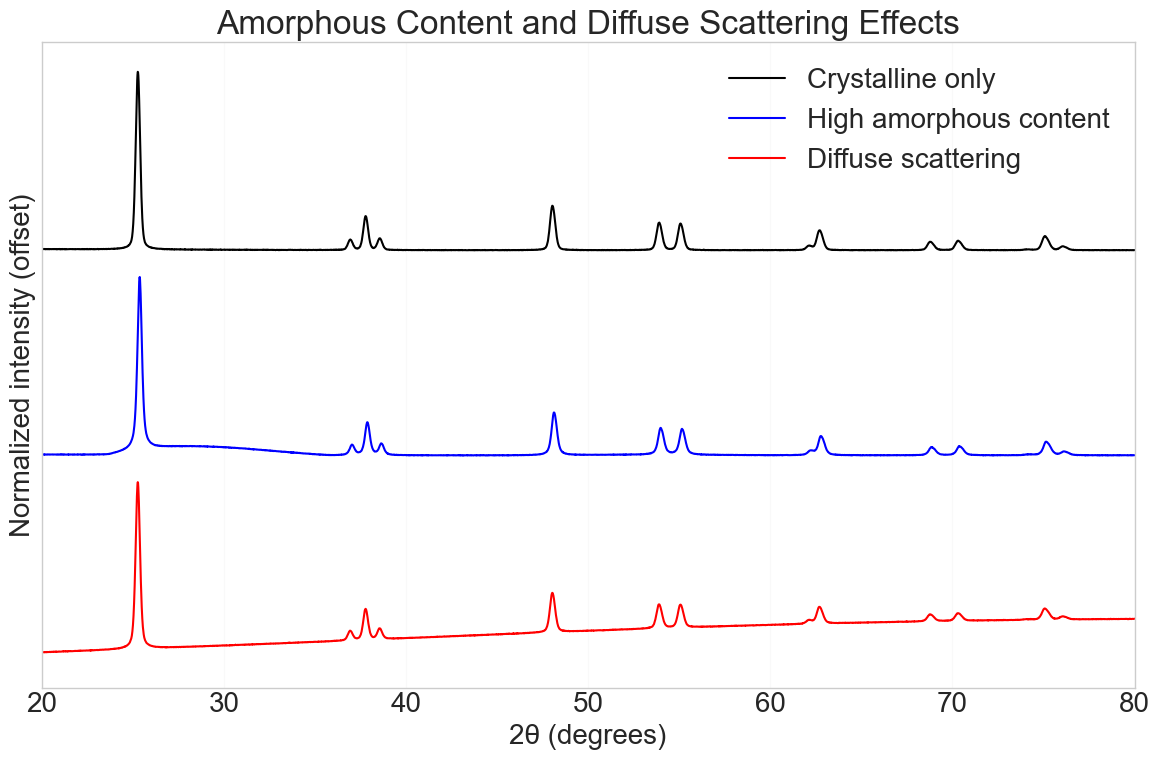

In [10]:
# Generate patterns with different amorphous and diffuse scattering content
amorphous_patterns = {}

amorphous_scenarios = {
    'Crystalline only': {'amorphous': (0.0, 0.0), 'diffuse': (0.0, 0.0)},
    'High amorphous content': {'amorphous': (100.0, 100.0), 'diffuse': (0.0, 0.0)},
    'Diffuse scattering': {'amorphous': (0.0, 0.0), 'diffuse': (100.0, 100.0)}
}

for scenario_label, intensities in amorphous_scenarios.items():
    amorphous_config = XRDGenerationConfig(
        min_angle=10.0, max_angle=80.0,
        uniform_shift_range=(0.0, 0.0),
        crystallite_size_range=(30.0, 30.0),
        microstrain_range=(0.0, 0.0),
        lattice_strain_range=(0.0, 0.0),
        temperature_range=(300, 300),
        texture_range=(1.0, 1.0),
        background_level=(1.0, 1.0),
        noise_level=(0.05, 0.05),
        diffuse_scattering_intensity=intensities['diffuse'],     # TEMPERATURE-DIFFUSE SCATTERING
        amorphous_intensity=intensities['amorphous'],            # AMORPHOUS IMPURITY PHASE
        enable_impurities=False
    )

    gen = UnifiedPatternGenerator(reference_dir=str(cif_dir), config=amorphous_config)
    pattern = gen.generate_single_phase_pattern(
        cif_file=str(cif_dir / "TiO2_121632.cif"),
        target_concentration=1.0
    )
    amorphous_patterns[scenario_label] = pattern

# Plot amorphous and diffuse scattering effects
print('\n')
fig, ax = plt.subplots(figsize=(12, 8))
colors = ['black', 'blue', 'red', 'orange']

# Scale each pattern to a common peak height before stacking
for i, (label, pattern) in enumerate(amorphous_patterns.items()):
    intensity = np.asarray(pattern['intensity'], dtype=float)
    ax.plot(pattern['two_theta'], intensity / intensity.max() - i * 1.15,
            color=colors[i], label=label, linewidth=1.5)

ax.set_xlabel("2θ (degrees)")
ax.set_ylabel("Normalized intensity (offset)")
ax.set_title("Amorphous Content and Diffuse Scattering Effects")
ax.legend()
ax.grid(True, alpha=0.1)
ax.set_xlim(20, 80)
ax.set_yticks([])

plt.tight_layout()
plt.savefig(results_dir / "amorphous_diffuse_effects.png", dpi=300, bbox_inches='tight')
plt.show()

High amorphous content leads to a broad "hump" in the pattern, while temperature-diffuse scattering leads to increased background intensity at high angles.

#### Q-space Conversion

XRD patterns are traditionally plotted as intensity vs. 2θ (scattering angle), but they can also be converted to Q-space (reciprocal space) for analysis. This may or may not provide a benefit for ML - some testing needs to be done so we can understand which gives better results.

The conversion is given by: **q = (4π/λ)sin(θ)** where λ is the X-ray wavelength and θ is half the scattering angle (2θ/2).

Let's generate patterns in both 2θ and Q-space to compare them:

Discovered 18 reference phases (structures will be lazily loaded)
Discovered 18 reference phases (structures will be lazily loaded)
Generated patterns in both 2θ and Q-space
2θ pattern: x-range 10.0 to 120.0 degrees
Q-space pattern: x-range 0.71 to 7.06 Å⁻¹


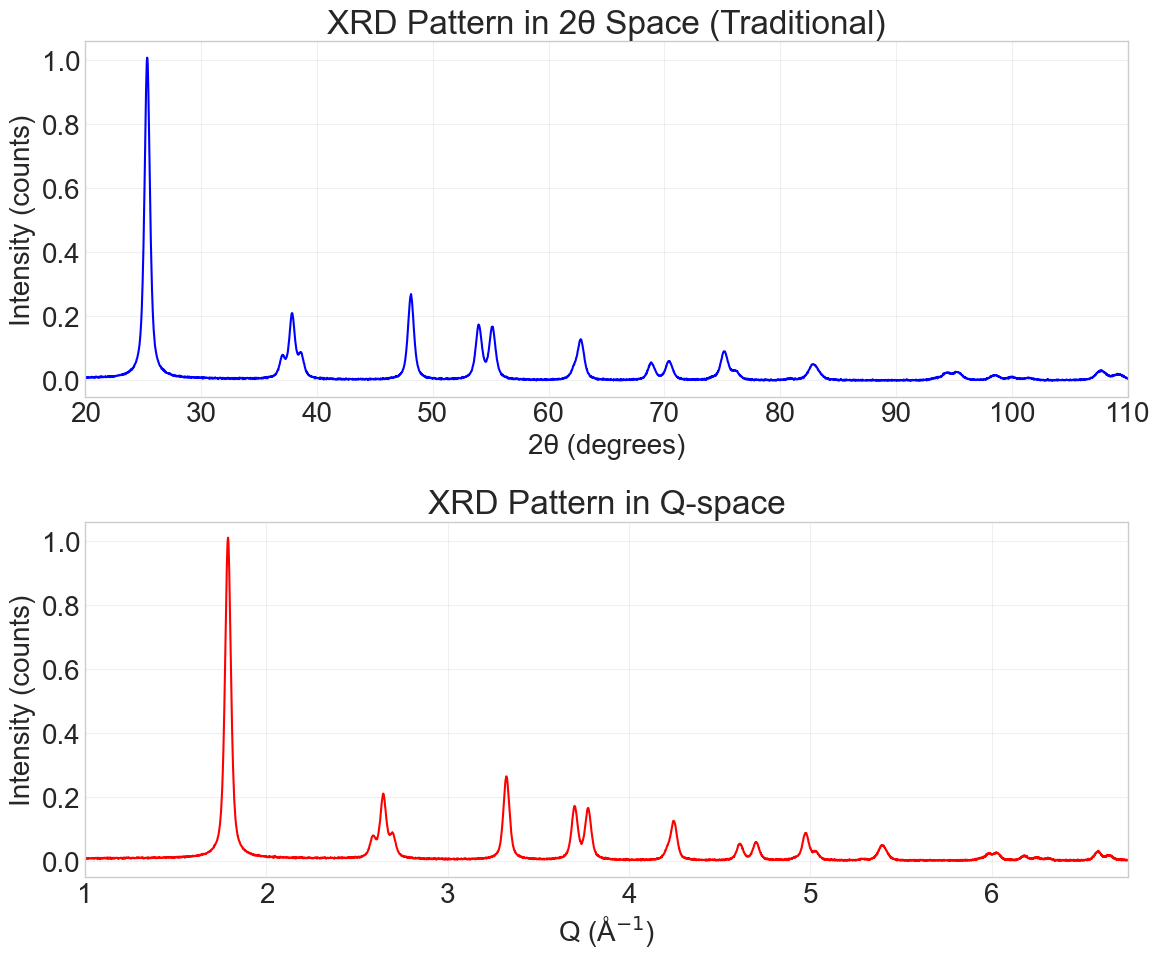


Comparison saved to results/qspace_comparison.png


In [11]:
# Generate patterns in both 2θ and Q-space for comparison

# Configuration for 2θ space (traditional)
twotheta_config = XRDGenerationConfig(
    min_angle=10.0, max_angle=120.0,
    convert_to_q=False,  # Traditional 2θ space
    uniform_shift_range=(0.0, 0.0),
    crystallite_size_range=(15.0, 15.0),
    microstrain_range=(0.0, 0.0),
    lattice_strain_range=(0.0, 0.0),
    temperature_range=(300, 300),
    texture_range=(1.0, 1.0),
    background_level=(1.0, 1.0),
    noise_level=(0.1, 0.1),
    diffuse_scattering_intensity=(0.0, 0.0),
    amorphous_intensity=(0.0, 0.0),
    enable_impurities=False
)

# Configuration for Q-space
qspace_config = XRDGenerationConfig(
    min_angle=10.0, max_angle=120.0,
    convert_to_q=True,   # Convert to Q-space
    uniform_shift_range=(0.0, 0.0),
    crystallite_size_range=(15.0, 15.0),
    microstrain_range=(0.0, 0.0),
    lattice_strain_range=(0.0, 0.0),
    temperature_range=(300, 300),
    texture_range=(1.0, 1.0),
    background_level=(1.0, 1.0),
    noise_level=(0.1, 0.1),
    diffuse_scattering_intensity=(0.0, 0.0),
    amorphous_intensity=(0.0, 0.0),
    enable_impurities=False
)

# Generate patterns in both spaces
gen_2theta = UnifiedPatternGenerator(reference_dir=str(cif_dir), config=twotheta_config)
gen_qspace = UnifiedPatternGenerator(reference_dir=str(cif_dir), config=qspace_config)

pattern_2theta = gen_2theta.generate_single_phase_pattern(
    cif_file=str(cif_dir / "TiO2_121632.cif"),
    target_concentration=1.0
)

pattern_qspace = gen_qspace.generate_single_phase_pattern(
    cif_file=str(cif_dir / "TiO2_121632.cif"),
    target_concentration=1.0
)

print("Generated patterns in both 2θ and Q-space")
print(f"2θ pattern: x-range {pattern_2theta['two_theta'].min():.1f} to {pattern_2theta['two_theta'].max():.1f} degrees")
print(f"Q-space pattern: x-range {pattern_qspace['two_theta'].min():.2f} to {pattern_qspace['two_theta'].max():.2f} Å⁻¹")

# Plot both patterns for comparison
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Top plot: Traditional 2θ space
visualizer.plot_pattern(
    x_values=pattern_2theta['two_theta'],
    intensity=pattern_2theta['intensity'],
    xlabel='2θ (degrees)',
    ylabel='Intensity (counts)',
    color='blue',
    show=False
)
ax1.plot(pattern_2theta['two_theta'], pattern_2theta['intensity'], 
         color='blue', linewidth=1.5)
ax1.set_xlabel('2θ (degrees)')
ax1.set_ylabel('Intensity (counts)')
ax1.set_title('XRD Pattern in 2θ Space (Traditional)')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(20, 110)

# Bottom plot: Q-space
ax2.plot(pattern_qspace['two_theta'], pattern_qspace['intensity'], 
         color='red', linewidth=1.5)
ax2.set_xlabel('Q (Å$^{-1}$)')
ax2.set_ylabel('Intensity (counts)')
ax2.set_title('XRD Pattern in Q-space')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(1, 6.75)

plt.tight_layout()
plt.savefig(results_dir / "qspace_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"\nComparison saved to {results_dir / 'qspace_comparison.png'}")


Notice that in Q-space, peaks are a little bit more evenly distributed, whereas in 2θ space they become more compressed at higher angles.

Simulating patterns in Q-space may also be helpful because it mitigates the effects of peak broadening that are more prominent at high 2θ.

## 5. Multi-Phase Pattern Generation

Now let's generate patterns containing mixtures of multiple phases:


Generating multi-phase pattern:
  - TiO2_121632: 50.0%
  - Li2CO3_100324: 30.0%
  - LiMn2O4_111081: 20.0%
Discovered 18 reference phases (structures will be lazily loaded)




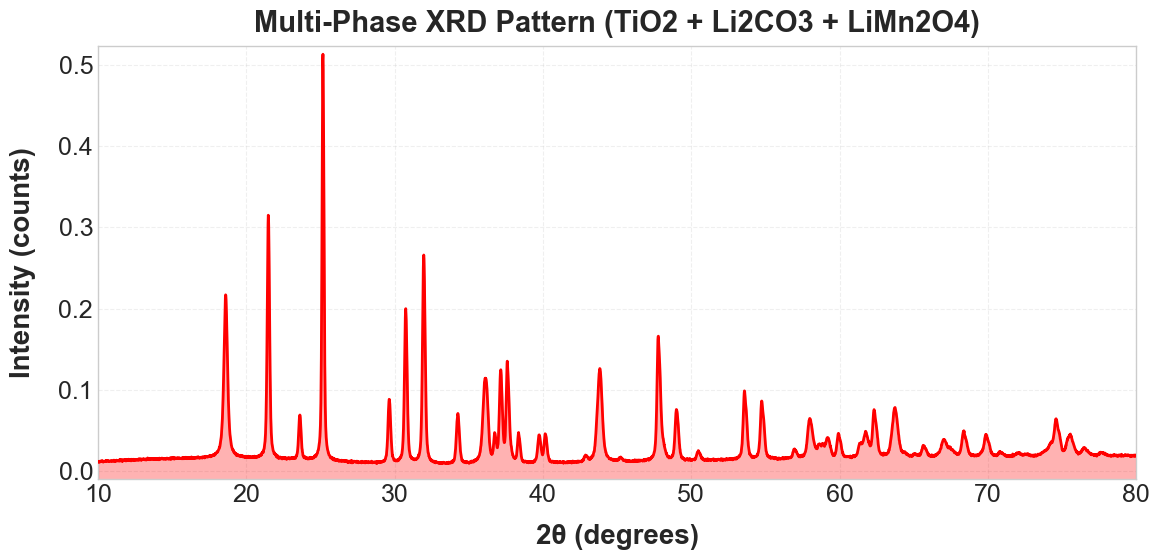

<Figure size 640x480 with 0 Axes>

In [12]:
# Select multiple CIF files for a mixture
cif_files = [
    cif_dir / "TiO2_121632.cif",      # Anatase
    cif_dir / "Li2CO3_100324.cif",    # Lithium carbonate
    cif_dir / "LiMn2O4_111081.cif"    # Lithium manganese oxide
]

# Define phase concentrations (must sum to 1.0)
concentrations = [0.5, 0.3, 0.2]  # 50% TiO2, 30% Li2CO3, 20% LiMn2O4

print(f"\nGenerating multi-phase pattern:")
for cif, conc in zip(cif_files, concentrations):
    print(f"  - {cif.stem}: {conc*100:.1f}%")

# Generate multi-phase pattern
multi_config = XRDGenerationConfig(
    min_angle=10.0,
    max_angle=80.0,
    uniform_shift_range=(-0.1, 0.1),
    crystallite_size_range=(20.0, 80.0),
    microstrain_range=(0.0, 0.002),
    lattice_strain_range=(0.0, 0.01),
    temperature_range=(250, 350),
    texture_range=(0.8, 1.2),
    background_level=(1.0, 4.0),
    noise_level=(0.0, 0.1),
    diffuse_scattering_intensity=(5.0, 10.0),
    amorphous_intensity=(0.0, 0.0),
    enable_impurities=True,
    impurity_intensity_range=(0.0, 0.0)
)

multi_generator = UnifiedPatternGenerator(reference_dir=str(cif_dir), config=multi_config)

mixture_pattern = multi_generator.generate_multi_phase_pattern(
    cif_files=[str(f) for f in cif_files],
    concentrations=concentrations,
    include_metadata=True
)

# Plot the mixture pattern
print('\n')
fig, ax = visualizer.plot_pattern(
    x_values=mixture_pattern['two_theta'],
    intensity=mixture_pattern['intensity'],
    title="Multi-Phase XRD Pattern (TiO2 + Li2CO3 + LiMn2O4)",
    xlabel="2θ (degrees)",
    ylabel="Intensity (counts)",
    color='red'
)

# Add concentration information
conc_text = "Phase Concentrations:\n"
for cif, conc in zip(cif_files, concentrations):
    conc_text += f"{cif.stem}: {conc*100:.1f}%\n"

ax.text(0.02, 0.98, conc_text, transform=ax.transAxes,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.8))

plt.tight_layout()
plt.savefig(results_dir / "multi_phase_pattern.png", dpi=300, bbox_inches='tight')
plt.show()

## 6. Adding a Realistic Combination of Artifacts

Real XRD measurements contain a mix of various artifacts. We can include them stochastically, all at once, and visualize how they affect the generated patterns.


Generating patterns with realistic artifacts...
Discovered 18 reference phases (structures will be lazily loaded)
Pattern 1: crystallite size = 47.7 nm
Discovered 18 reference phases (structures will be lazily loaded)
Pattern 2: crystallite size = 38.3 nm
Discovered 18 reference phases (structures will be lazily loaded)
Pattern 3: crystallite size = 24.9 nm
Discovered 18 reference phases (structures will be lazily loaded)
Pattern 4: crystallite size = 41.4 nm
Discovered 18 reference phases (structures will be lazily loaded)
Pattern 5: crystallite size = 19.3 nm




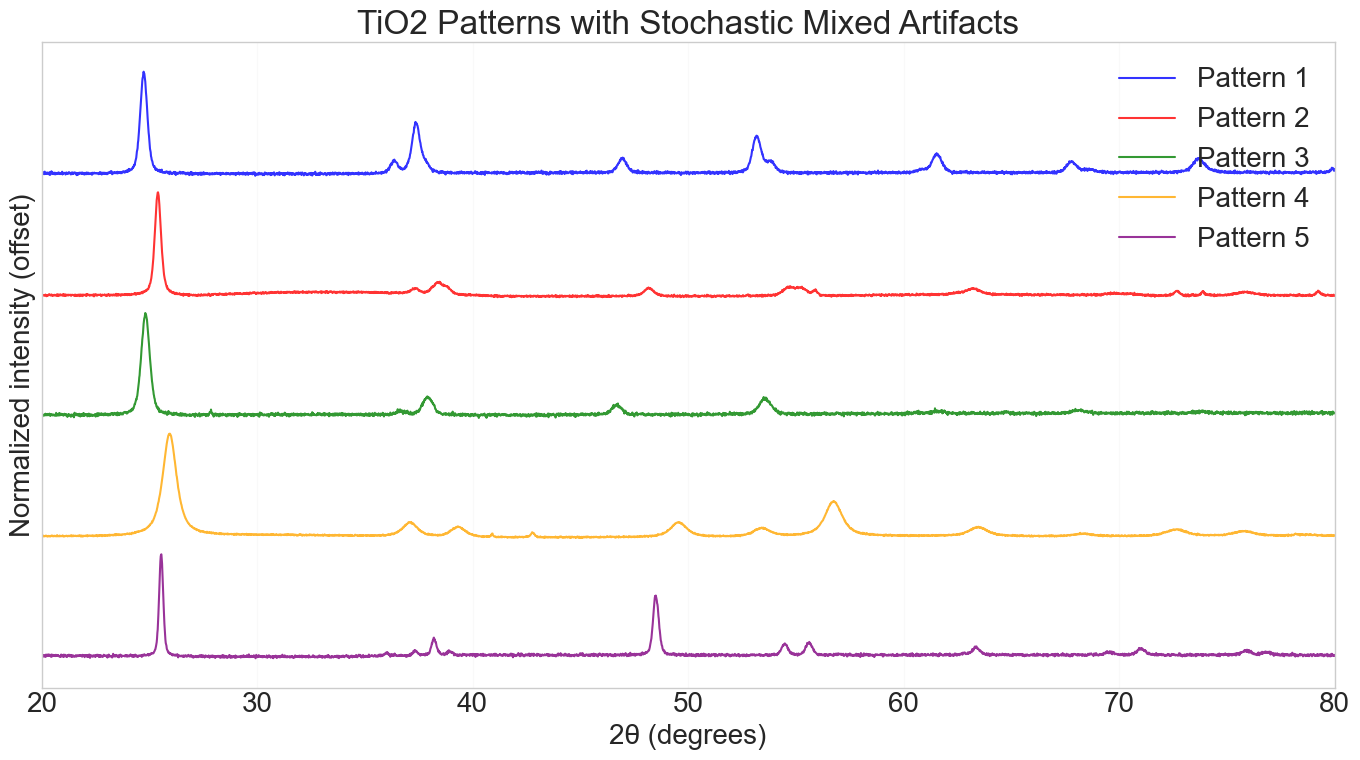

In [13]:
# Configuration with enhanced artifacts
artifact_config = XRDGenerationConfig(

    min_angle=10.0,
    max_angle=80.0,
    num_points=4501,

    # All the below arguments define a RANGE of values
    # over which artifacts will be randomly sampled

    # These ranges should be chosen carefully to
    # reflect what is realistic in experiment.
    
    uniform_shift_range=(-0.2, 0.2),
    sample_displacement=(-0.1, 0.1),

    crystallite_size_range=(10.0, 50.0),
    microstrain_range=(0.0, 0.005),
    lattice_strain_range=(0.0, 0.04),

    temperature_range=(200, 800),
    atomic_displacement_range=(0.01, 0.05),

    texture_range=(0.5, 1.5),

    background_level=(0.5, 5.0),
    noise_level=(0.1, 0.8),

    diffuse_scattering_intensity=(10.0, 20.0),
    amorphous_intensity=(10.0, 40.0),

    # Also include minor impurities
    enable_impurities=True,
    impurity_intensity_range=(0.0, 5.0)
)

print("\nGenerating patterns with realistic artifacts...")

# Generate multiple patterns to show variability
artifact_patterns = []
for i in range(5):
    pattern = UnifiedPatternGenerator(reference_dir=str(cif_dir), config=artifact_config).generate_single_phase_pattern(
        cif_file=str(cif_dir / "TiO2_121632.cif"),
        target_concentration=1.0,
        include_metadata=True
    )
    artifact_patterns.append(pattern)
    print(f"Pattern {i+1}: crystallite size = {pattern['metadata']['crystallite_size']:.1f} nm")

# Plot all patterns for comparison
print('\n')
fig, ax = plt.subplots(figsize=(14, 8))
colors = ['blue', 'red', 'green', 'orange', 'purple']

# Scale each pattern to a common peak height before stacking
for i, pattern in enumerate(artifact_patterns):
    intensity = np.asarray(pattern['intensity'], dtype=float)
    ax.plot(pattern['two_theta'], intensity / intensity.max() - i * 1.15,
            color=colors[i], label=f"Pattern {i+1}", alpha=0.8, linewidth=1.5)

ax.set_xlabel("2θ (degrees)")
ax.set_ylabel("Normalized intensity (offset)")
ax.set_title("TiO2 Patterns with Stochastic Mixed Artifacts")
ax.legend()
ax.grid(True, alpha=0.1)
ax.set_xlim(20, 80)
ax.set_yticks([])

plt.tight_layout()
plt.savefig(results_dir / "artifact_patterns.png", dpi=300, bbox_inches='tight')
plt.show()


The noticable differences in these patterns gives you some idea of how much variability there can be for a (seemingly) simple 1-phase sample.

This is (in part) why traditional methods of phase detection often fail, and why machine learning is needed to *learn* these changes.

Multi-phase mixtures complicate things even further - and we need to simulate them (as shown in Step 5) for model training.